<a href="https://colab.research.google.com/github/alicienty/HW2/blob/main/Lukyanchikova_ml_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание: обучение CNN на собранном корпусе данных

## Задача

1. Собрать свой текстовый корпус (не менее 500 примеров) с помощью библиотеки `requests` или другого инструмента парсинга.
2. Выполнить разметку собранных данных для задачи классификации (бинарной или многоклассовой).
3. Обучить свёрточную нейросеть (CNN) на собранных и размеченных данных с использованием PyTorch или TensorFlow на выбор.
4. Самостоятельно подобрать архитектуру модели и гиперпараметры (количество слоёв, размер ядра, функцию активации, оптимизатор и т.д.).
5. После обучения вывести на экран метрики качества (accuracy, precision, recall, F1-score) на тестовой выборке.

# 0. Импорты

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from collections import Counter
import numpy as np
import torch
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch.optim as optim
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# 1. Задача

Есть датасет отзывов с irecommend.ru. Будем предсказывать рейтинг, который пользователь присвоил отзыву, по тексту и заголовку отзыва

# 2. Сбор корпуса: парсинг и разметка

Итоговый парсер выглядел так:

In [ ]:
import asyncio
import json
import re
from playwright.async_api import async_playwright


async def main():
    with open("results.json", "r", encoding="utf-8") as f:
        books = json.load(f)

    try:
        with open("new_results.json", "r", encoding="utf-8") as f:
            saved = json.load(f)
    except:
        saved = []

    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False)
        page = await browser.new_page()

        for idx, book in enumerate(books):
            if any(b.get("link") == book["link"] and b.get("author") for b in saved):
                continue

            print(f"\n📖 {idx + 1}/{len(books)}: {book['name'][:50]}")

            try:
                await page.goto(book["link"], timeout=30000)
                await asyncio.sleep(2)

                author = await page.text_content('.voc-group.vid-13 a') or ""
                category = await page.text_content('.voc-group.vid-1 a') or ""
                genre_elems = await page.query_selector_all('.voc-group.vid-19 a')
                genre = ", ".join([await g.text_content() for g in genre_elems]) if genre_elems else ""
                rating = await page.text_content('.average-rating .rating') or ""

                review_urls = []
                links = await page.query_selector_all('.list-comments .reviewTextSnippet')
                for link in links[:25]:
                    href = await link.get_attribute("href")
                    if href:
                        review_urls.append(f"https://irecommend.ru{href}" if not href.startswith('http') else href)

                print(f"   📝 Отзывов: {len(review_urls)}")

                reviews = []
                for i, review_url in enumerate(review_urls):
                    try:
                        print(f"   🔄 {i + 1}/{len(review_urls)}")
                        await page.goto(review_url, timeout=15000)
                        await asyncio.sleep(2)

                        # Проверяем наличие элемента с таймаутом 5 секунд
                        try:
                            await page.wait_for_selector('.reviewText .description', timeout=5000)
                        except:
                            print(f"      ⚠️ Нет текста отзыва, пропускаем")
                            continue

                        title = await page.text_content('.reviewTitle') or ""
                        text = await page.text_content('.reviewText .description') or ""
                        author_review = await page.text_content('.reviewer a') or ""
                        rating_review = await page.get_attribute('.starsRating meta[itemprop="ratingValue"]',
                                                                 'content') or ""
                        date = re.sub(r'Опубликовано\s+', '', await page.text_content('.dtreviewed') or "")

                        reviews.append({
                            "author_review": author_review.strip(),
                            "rating_review": rating_review,
                            "date_review": date.strip(),
                            "title_review": title.strip(),
                            "text_review": re.sub(r'\n+', '\n', text).strip()
                        })

                    except Exception as e:
                        print(f"      ❌ {str(e)[:50]}")
                        continue

                book.update({"author": author.strip(), "category": category.strip(), "genre": genre.strip(),
                             "rating": rating.strip(), "reviews": reviews})
                saved.append(book)

                with open("new_results.json", "w", encoding="utf-8") as f:
                    json.dump(saved, f, indent=4, ensure_ascii=False)

                print(f"   ✅ {author} | отзывов: {len(reviews)}")

            except Exception as e:
                print(f"   ❌ {str(e)[:50]}")
                with open("new_results.json", "w", encoding="utf-8") as f:
                    json.dump(saved, f, indent=4, ensure_ascii=False)

        await browser.close()


asyncio.run(main())

*оформление и обработка ошибок были сделаны с помощью ЛЛМ

# 3. EDA

Загрузка датасета

In [3]:
df = pd.read_excel("/content/reviews_for_ml.xlsx")
df.head()

,id_отзыва,name_book,rating_book,author_book,category_book,genre_book,link_book,author_review,rating_review,date_review,title_review,text_review
0,1,"Операция ""Ух"", или Невеста для Горыныча. Диана...",5.0,Диана Соул,Книги / художественная литература,"Современная проза, Фэнтези",https://irecommend.ru/content/operatsiya-ukh-i...,Книжная полка,5,"13 Апрель, 2026 - 13:42","Потрясающая история, к которой хочется возвращ...","Операция ""Ух"", или Невеста для Горыныча Автор:..."
1,2,"Гарри Поттер и Узник Азкабана, Джоан Роулинг",4.9,Джоан Роулинг,Книги / художественная литература,"Зарубежная литература, Фэнтези",https://irecommend.ru/content/garri-potter-i-u...,happiness_inside,5,"11 Декабрь, 2025 - 22:12",Почему Гарри чуть не исключили из Хогвартса на...,Привет всем фанатам Гарри Поттера! 🧙К тому мом...
2,3,"Гарри Поттер и Узник Азкабана, Джоан Роулинг",4.9,Джоан Роулинг,Книги / художественная литература,"Зарубежная литература, Фэнтези",https://irecommend.ru/content/garri-potter-i-u...,mavava,5,"29 Январь, 2025 - 14:04","Одна из самых интересных частей для тех, кто у...","Всем привет! Я очень люблю Гарри Поттера, поэт..."
3,4,"Гарри Поттер и Узник Азкабана, Джоан Роулинг",4.9,Джоан Роулинг,Книги / художественная литература,"Зарубежная литература, Фэнтези",https://irecommend.ru/content/garri-potter-i-u...,kotelnikova_013,5,"13 Декабрь, 2024 - 16:17","Когда опасность подстерегает на каждом шагу, т...","Добрый день, дорогие читатели! Прошло уже 10 л..."
4,5,"Гарри Поттер и Узник Азкабана, Джоан Роулинг",4.9,Джоан Роулинг,Книги / художественная литература,"Зарубежная литература, Фэнтези",https://irecommend.ru/content/garri-potter-i-u...,anka Or88,5,"7 Сентябрь, 2024 - 15:44",Волшебное издание Узника Азкабана с иллюстраци...,Здравствуйте! Я отношу себя к фанатам Гарии По...


In [4]:
# размер датасета
print(f"Размер датасета: {df.shape}")

Размер датасета: (2872, 12)


In [4]:
# информация о столбцах
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2872 entries, 0 to 2871
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_отзыва      2872 non-null   int64  
 1   name_book      2872 non-null   object 
 2   rating_book    2872 non-null   float64
 3   author_book    2872 non-null   object 
 4   category_book  2872 non-null   object 
 5   genre_book     2872 non-null   object 
 6   link_book      2872 non-null   object 
 7   author_review  2872 non-null   object 
 8   rating_review  2872 non-null   int64  
 9   date_review    2872 non-null   object 
 10  title_review   2872 non-null   object 
 11  text_review    2872 non-null   object 
dtypes: float64(1), int64(2), object(9)
memory usage: 269.4+ KB


In [5]:
print("Пропуски:")
df.isna().sum()

Пропуски:


,0
id_отзыва,0
name_book,0
rating_book,0
author_book,0
category_book,0
genre_book,0
link_book,0
author_review,0
rating_review,0
date_review,0


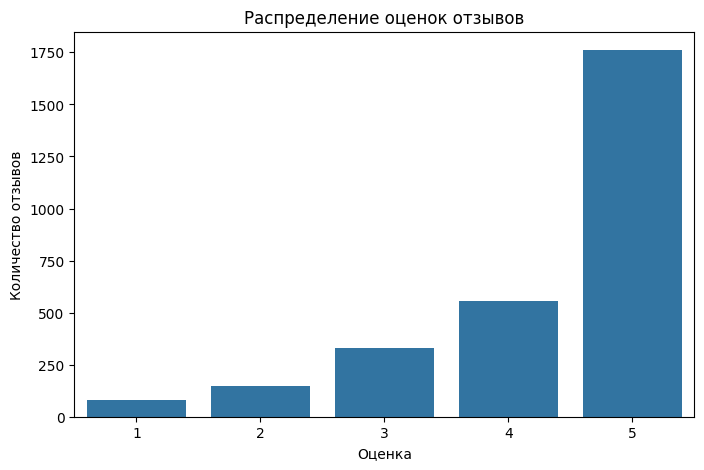

In [6]:
# распределение оценок
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='rating_review')
plt.title("Распределение оценок отзывов")
plt.xlabel("Оценка")
plt.ylabel("Количество отзывов")
plt.show()

In [7]:
df["review_length"] = df["text_review"].apply(lambda x: len(x.split()))

In [8]:
df["review_length"]

,review_length
0,138
1,1834
2,1130
3,1024
4,744
...,...
2867,402
2868,590
2869,355
2870,888


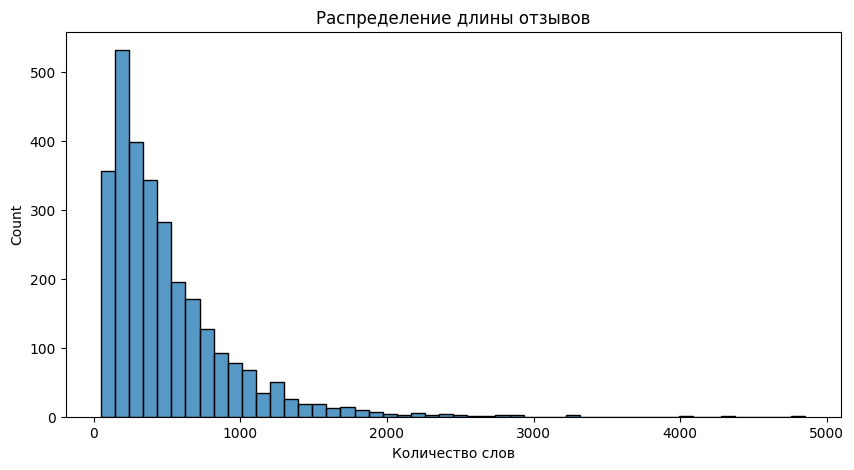

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(df["review_length"], bins=50)
plt.title("Распределение длины отзывов")
plt.xlabel("Количество слов")
plt.show()

In [16]:
print(df["review_length"].describe())

count    2872.000000
mean      500.512187
std       428.967653
min        50.000000
25%       211.000000
50%       378.000000
75%       648.250000
max      4854.000000
Name: review_length, dtype: float64


В корпусе есть заметный перекос в сторону текстов с положительной оценкой. Большинство текстов имеют длину от 100 до 900 слов.

Смотрим распределение средней длины по оценкам, заодно проверяем, действительно ли плохие отзывы длиннее

In [19]:
rating_lengths = (
    df.groupby("rating_review")["review_length"]
    .mean()
    .reset_index())

rating_lengths

,rating_review,review_length
0,1,526.762500
1,2,588.280822
2,3,559.612805
3,4,526.782765
4,5,472.725724


Больших изменений не видно, но среднее значение отзывов с оценкой 5 несколько длиннее. Надо проверять на статистическую значимость

# 4. Предобработка

Чистка

In [5]:
def clean_text(text):
    text = str(text).lower()

    # удаляем ссылки
    text = re.sub(r"http\S+", " ", text)

    # оставляем только буквы
    text = re.sub(r"[^а-яёa-z\s]", " ", text)

    # убираем лишние пробелы
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [6]:
# удаляем строки без текста или рейтинга
df = df.dropna(
    subset=[
        "title_review",
        "text_review",
        "rating_review"])

In [7]:
df["title_review"] = df["title_review"].apply(clean_text)
df["text_review"] = df["text_review"].apply(clean_text)

Объединяем название отзыва с его основным текстом — это может дать больше информации для обучения

In [8]:
df["full_text"] = (
    df["title_review"]
    + " "
    + df["text_review"])

Разделение выборки на тестовую/обучающую/валидационную выборки, подготовка целевой переменной

In [9]:
# готовим целевую переменную
# чтобы модель смогла ее обработать, смещаем оценки на 1 (от 0 до 4)
df["label"] = df["rating_review"].astype(int) - 1

In [10]:
df["label"]

,label
0,4
1,4
2,4
3,4
4,4
...,...
2867,2
2868,4
2869,4
2870,1


In [11]:
# готовим данные
X = df["full_text"]
y = df["label"]

In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y)

In [13]:
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp)

In [14]:
print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(2010,)
(431,)
(431,)


# 5. Создаем матрицы признаков

*нейроночка подсказала попробовать для создания эмбеддингов присвоить каждому слову уникальный индекс, пробую так вместо TF-IDF

Создаем словарь

In [15]:
MAX_VOCAB_SIZE = 10000

counter = Counter()

for text in X_train:
    counter.update(text.split())

In [16]:
most_common = counter.most_common(MAX_VOCAB_SIZE)

In [17]:
word2idx = {
    word: idx + 2
    for idx, (word, _) in enumerate(most_common)}

In [18]:
PAD_TOKEN = 0
UNK_TOKEN = 1

Кодируем тексты

In [19]:
def encode_text(text):
    return [
        word2idx.get(word, UNK_TOKEN)
        for word in text.split()]

In [20]:
X_train_encoded = X_train.apply(encode_text)
X_valid_encoded = X_valid.apply(encode_text)
X_test_encoded = X_test.apply(encode_text)

In [21]:
MAX_LEN = 500

In [22]:
def pad_sequence(sequence, max_len):

    if len(sequence) >= max_len:
        return sequence[:max_len]

    return sequence + [PAD_TOKEN] * (max_len - len(sequence))

Формируем матрицы

In [23]:
X_train_pad = np.array([
    pad_sequence(seq, MAX_LEN)
    for seq in X_train_encoded])

X_valid_pad = np.array([
    pad_sequence(seq, MAX_LEN)
    for seq in X_valid_encoded])

X_test_pad = np.array([
    pad_sequence(seq, MAX_LEN)
    for seq in X_test_encoded])

Создаем векторы меток

In [24]:
y_train = y_train.values
y_valid = y_valid.values
y_test = y_test.values

In [25]:
print(X_train_pad.shape)
print(X_valid_pad.shape)
print(X_test_pad.shape)

(2010, 500)
(431, 500)
(431, 500)


In [26]:
print(X_train_pad[0][:30])

[  13  873   29  998   16  604    2  604  375  160 1858 1490  154    1
    6   92   34   19    1   40    8 5266    1   11    1    1  379   17
   15   83]


# 6. Оборачиваем в датасет

In [27]:
# тензоры
X_train_tensor = torch.tensor(X_train_pad, dtype=torch.long)
X_valid_tensor = torch.tensor(X_valid_pad, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_pad, dtype=torch.long)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_valid_tensor = torch.tensor(y_valid, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [28]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor)

valid_dataset = TensorDataset(
    X_valid_tensor,
    y_valid_tensor)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor)

In [29]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False)

# 7. Обучение

CNN (архитектура)

Обоснование гиперпараметров:

* embedding_dim = 64
Был выбран средний размер эмбеддингов, поскольку меньший размер может быть недостаточен для нашего набора текстов, а больший, наоборот, избыточен и будет вести к переобучению. Был опробован размер 128 — на нем модель слишком быстро переобучалась и показывала результаты хуже, чем при 64
* kernel sizes = 3
Модель учитывает 3-граммы, наиболее универсальная величина для поиска отличительных деталей в тексте
* dropout = 0.5
Выбрано стандартное значение, поскольку датасет сравнительно небольшой
* lr = 0.001
Дефолтное значение, больших проблем с переобучением нет
* 5 эпох
На этом значении модель выдает максимальные результаты, с 6 эпохи начинается сильное переобучение, на 5 более равномерно распределяет отзывы (на 4 эпохе все относит к оценке 4, на 6 эпохе — к оценке 5)
* vocab_size = 10 тыс.
* MAX_LEN = 500
Размер словаря и максимальная длина были уменьшены для повышения качества — при таких значениях модель стала распределять значения между двумя наиболее частотными классами

In [62]:
class CNN1D(nn.Module):
    def __init__(self, vocab_size, embedding_dim, input_dim, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.conv1 = nn.Conv1d(embedding_dim, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(64 * (input_dim // 4), 128)
        self.fc2 = nn.Linear(128, num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.embedding(x)
        x = x.permute(0, 2, 1)

        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Создаем модель

In [125]:
VOCAB_SIZE = len(word2idx) + 2
EMBEDDING_DIM = 64
INPUT_DIM = MAX_LEN
NUM_CLASSES = 5

In [126]:
model = CNN1D(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    input_dim=INPUT_DIM,
    num_classes=NUM_CLASSES
)

Подбираем веса, поскольку данные распределены неравномерно

In [127]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

In [128]:
print(class_weights)

tensor([7.1786, 3.9412, 1.7478, 1.0308, 0.3263])


Функция потерь

In [129]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

Оптимизатор

In [130]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

Само обучение

In [131]:
EPOCHS = 5

for epoch in range(EPOCHS):
    total_loss = 0

    model.train()

    for batch_x, batch_y in train_loader:

        optimizer.zero_grad()

        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 1.6237
Epoch 2, Loss: 1.5864
Epoch 3, Loss: 1.4259
Epoch 4, Loss: 0.7371
Epoch 5, Loss: 0.3013


# 8. Анализ результатов (метрики, матрицы)

In [133]:
model.eval()

all_preds = []
all_true = []

with torch.no_grad():

    for batch_x, batch_y in test_loader:

        outputs = model(batch_x)

        preds = torch.argmax(
            outputs,
            dim=1
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_true.extend(
            batch_y.cpu().numpy()
        )

In [134]:
print(
    classification_report(
        all_true,
        all_preds
    )
)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.00      0.00      0.00        22
           2       0.10      0.16      0.12        49
           3       0.21      0.19      0.20        84
           4       0.65      0.66      0.65       264

    accuracy                           0.46       431
   macro avg       0.19      0.20      0.20       431
weighted avg       0.45      0.46      0.45       431



In [135]:
cm = confusion_matrix(
    all_true,
    all_preds
)

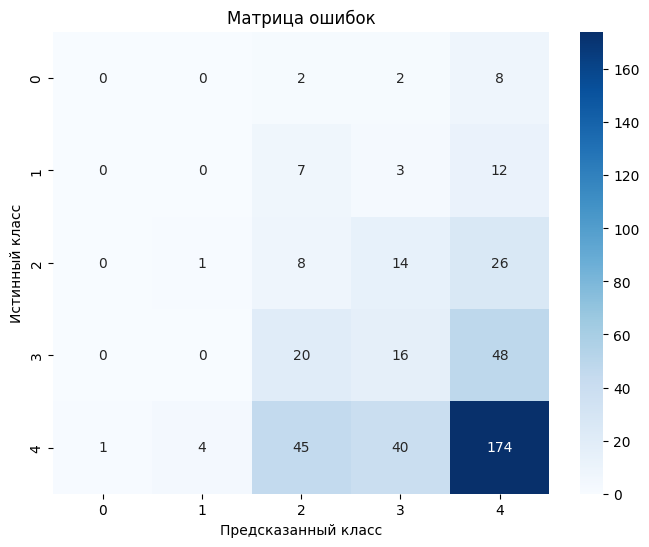

In [136]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")

plt.title("Матрица ошибок")

plt.show()

# Вывод

Модель демонстрирует умеренное качество классификации текстовых отзывов со следующими характеристиками:

Accuracy = 0.46
F1-score = 0.45

Модель правильно предсказывает чуть меньше половины тестовых примеров. Такие результаты могут быть обусловлены сильным дисбалансом и преобладанием положительных отзывов во всей выборке. Кроме того, задача осложняется тем, что лексика внутри отзывов со смежными рейтингами различается с трудом. Тем не менее, плохие отзывы практически не выделяются моделью и с большой вероятностью относятся к оценке 5 (модель не распознает эти классы) — доминирующей в датасете

Улучшения

Попробовать использовать предобученные эмбеддинги
Использовать модель, которая лучше хранит длинные зависимости в тексте
Сбалансировать данные


## Критерии оценки (10-балльная шкала)

| Баллы | Критерий |
|-------|----------|
| 1 | Корпус собран, объём ≥ 500 примеров |
| 2 | Корпус размечен (указаны классы для каждого примера) |
| 3 | Данные предобработаны и разделены на обучающую/валидационную/тестовую выборки |
| 4 | Модель CNN реализована (TensorFlow или PyTorch) и запущена на обучение |
| 5 | Обучение завершено без ошибок, модель сохраняет веса |
| 6 | Выведены базовые метрики (accuracy) на тестовой выборке |
| 7 | Выведен полный набор метрик: precision, recall, F1-score |
| 8 | Гиперпараметры подобраны обоснованно (с комментариями, почему выбраны именно такие значения) |
| 9 | Проведён анализ результатов (что получилось хорошо, что можно улучшить) |
| 10 | Код полностью воспроизводим, содержит комментарии, структура соответствует лучшим практикам |

## Важно

- Качество модели (точность) не является основным критерием — важнее корректность выполнения всех этапов.
- Выберите **свой уникальный источник данных** для парсинга и укажите его в отчёте.
- Разметка должна быть выполнена вручную или с помощью автоматических правил (например, по ключевым словам или меткам с сайта). Укажите способ разметки.
- Не используйте готовые датасеты из интернета (например, IMDB, MNIST, CIFAR).
- Для текстовых данных CNN обычно работает на уровне слов или символов — обоснуйте выбранный подход.

## Рекомендации по выполнению

1. **Выбор источника данных:** новостной сайт с категориями, отзывы пользователей (позитивные/негативные), посты с форума по разным темам, заголовки новостей с метками и т.д.
2. **Разметка:** можно использовать структуру сайта (например, раздел "спорт" — класс 0, раздел "политика" — класс 1) или выполнить разметку вручную для небольшого корпуса.
3. **Архитектура CNN для текста:** Embedding → Conv1D → GlobalMaxPooling1D → Dense → Dropout → Dense(классы).
4. **Гиперпараметры для подбора:** размер эмбеддингов (50–300), количество фильтров (32–256), размер ядра (3–5), dropout rate (0.3–0.7), скорость обучения.
5. **Минимальный размер корпуса:** 500 размеченных примеров. При недостаточном количестве данных используйте аугментацию или меньшую модель.